# Medica Risk Stratification
In this notebook, we develop machine learning models to classify individuals into different medical risk levels based on demographic, lifestyle, and clinical features. Two risk-stratification approaches are explored: a three-class model (low, medium, high) and a simplified binary model (low vs. high). By comparing their performance and interpretability, we aim to determine which classification method provides the most practical value for healthcare screening and early-risk detection.



---


#### Sebastian HUARACA LAPA
#### Nicole VERZA DOS SANTOS


---



## Importation

In [99]:

# ======================================
# INSTALLATION
# ======================================
%pip install optuna

# ======================================
# DATA MANIPULATION
# ======================================
import pandas as pd
import numpy as np

# ======================================
# DATA VISUALIZATION
# ======================================
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ======================================
# STATISTICAL TESTS
# ======================================
from scipy.stats import chi2_contingency, kruskal, f_oneway

# ======================================
# MACHINE LEARNING
# ======================================
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ======================================
# DEEP LEARNING (PyTorch)
# ======================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# ======================================
# HYPERPARAMETER OPTIMIZATION
# ======================================
import optuna

Note: you may need to restart the kernel to use updated packages.


C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset

In [100]:
url = "https://raw.githubusercontent.com/Sebasss-h/Medical-Insurance-Cost-Prediction-using-Machine-Learning/refs/heads/main/Data/medical_insurance.csv"
df = pd.read_csv("Data/medical_insurance.csv")
df

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0


## Descriptive analysis


In [101]:
print("Dataset dimensions:", df.shape)
print("\nData types:")
print(df.dtypes)

Dataset dimensions: (100000, 54)

Data types:
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible        

In [102]:
df=df.drop('person_id',axis=1)

In [103]:
num_vars = df.select_dtypes(include=['number']).columns
cat_vars = df.select_dtypes(exclude=['number']).columns

print("Numerical variables:", len(num_vars), "\n", list(num_vars))
print("\nCategorical variables:", len(cat_vars), "\n", list(cat_vars))

Numerical variables: 43 
 ['age', 'income', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Categorical variables: 10 
 ['sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier']


In [104]:
print("NaN or missing data:")
print(df.isnull().sum())

NaN or missing data:
age                                0
sex                                0
region                             0
urban_rural                        0
income                             0
education                          0
marital_status                     0
employment_status                  0
household_size                     0
dependents                         0
bmi                                0
smoker                             0
alcohol_freq                   30083
visits_last_year                   0
hospitalizations_last_3yrs         0
days_hospitalized_last_3yrs        0
medication_count                   0
systolic_bp                        0
diastolic_bp                       0
ldl                                0
hba1c                              0
plan_type                          0
network_tier                       0
deductible                         0
copay                              0
policy_term_years                  0
policy_changes_la

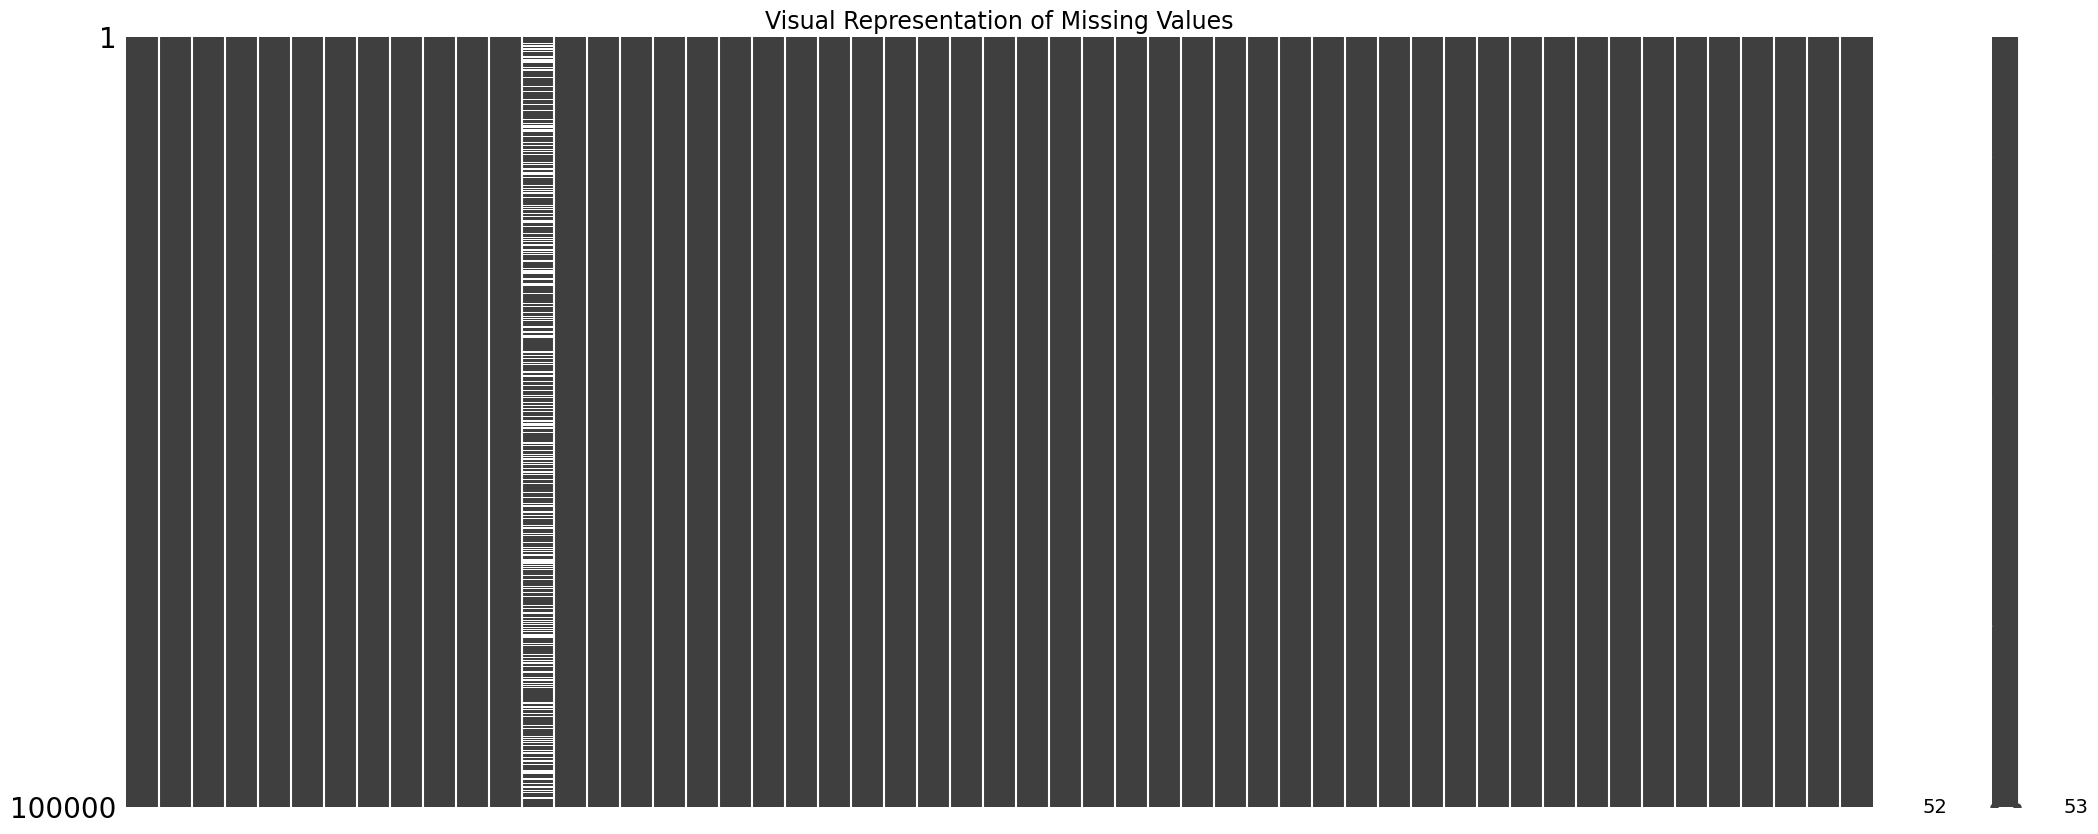

In [105]:
msno.matrix(df)
plt.title("Visual Representation of Missing Values", fontsize=17)
plt.show()

In [106]:
df['alcohol_freq'].unique()

array([nan, 'Weekly', 'Daily', 'Occasional'], dtype=object)

In [107]:
df_nan_alcohol_freq = df[df['alcohol_freq'].isna()].copy()
chronic_cols = [
    'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
    'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health'
]
df_nan_alcohol_freq['chronic_count'] = df_nan_alcohol_freq[chronic_cols].sum(axis=1)

df_nan_alcohol_freq['chronic_count'].describe()

count    30083.000000
mean         0.722102
std          0.803861
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          5.000000
Name: chronic_count, dtype: float64

The missing values in alcohol_freq correspond to individuals who are generally healthy (average number of chronic diseases = 0.72); therefore, we classify them as ‘Never’.

In [108]:
df['alcohol_freq']=df['alcohol_freq'].fillna('Never')

In [109]:
print("NaN or missing data:")
print(df.isnull().sum())

NaN or missing data:
age                            0
sex                            0
region                         0
urban_rural                    0
income                         0
education                      0
marital_status                 0
employment_status              0
household_size                 0
dependents                     0
bmi                            0
smoker                         0
alcohol_freq                   0
visits_last_year               0
hospitalizations_last_3yrs     0
days_hospitalized_last_3yrs    0
medication_count               0
systolic_bp                    0
diastolic_bp                   0
ldl                            0
hba1c                          0
plan_type                      0
network_tier                   0
deductible                     0
copay                          0
policy_term_years              0
policy_changes_last_2yrs       0
provider_quality               0
risk_score                     0
annual_medical_cost   

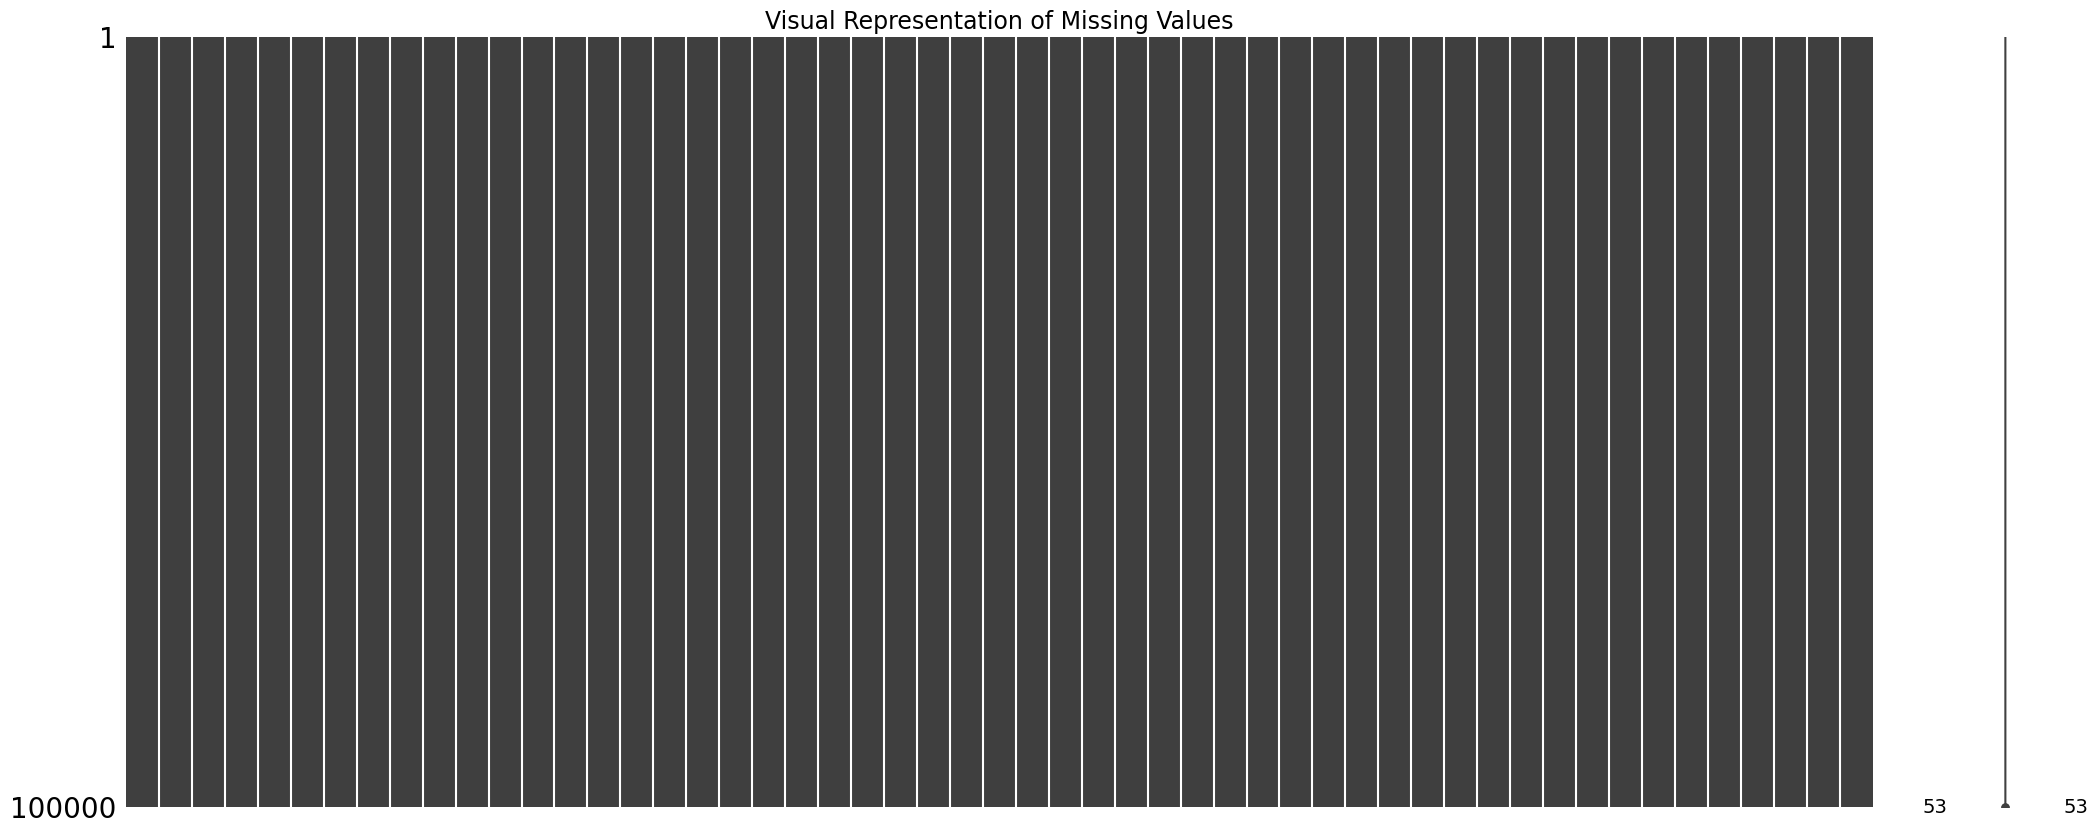

In [110]:
msno.matrix(df)
plt.title("Visual Representation of Missing Values", fontsize=17)
plt.show()

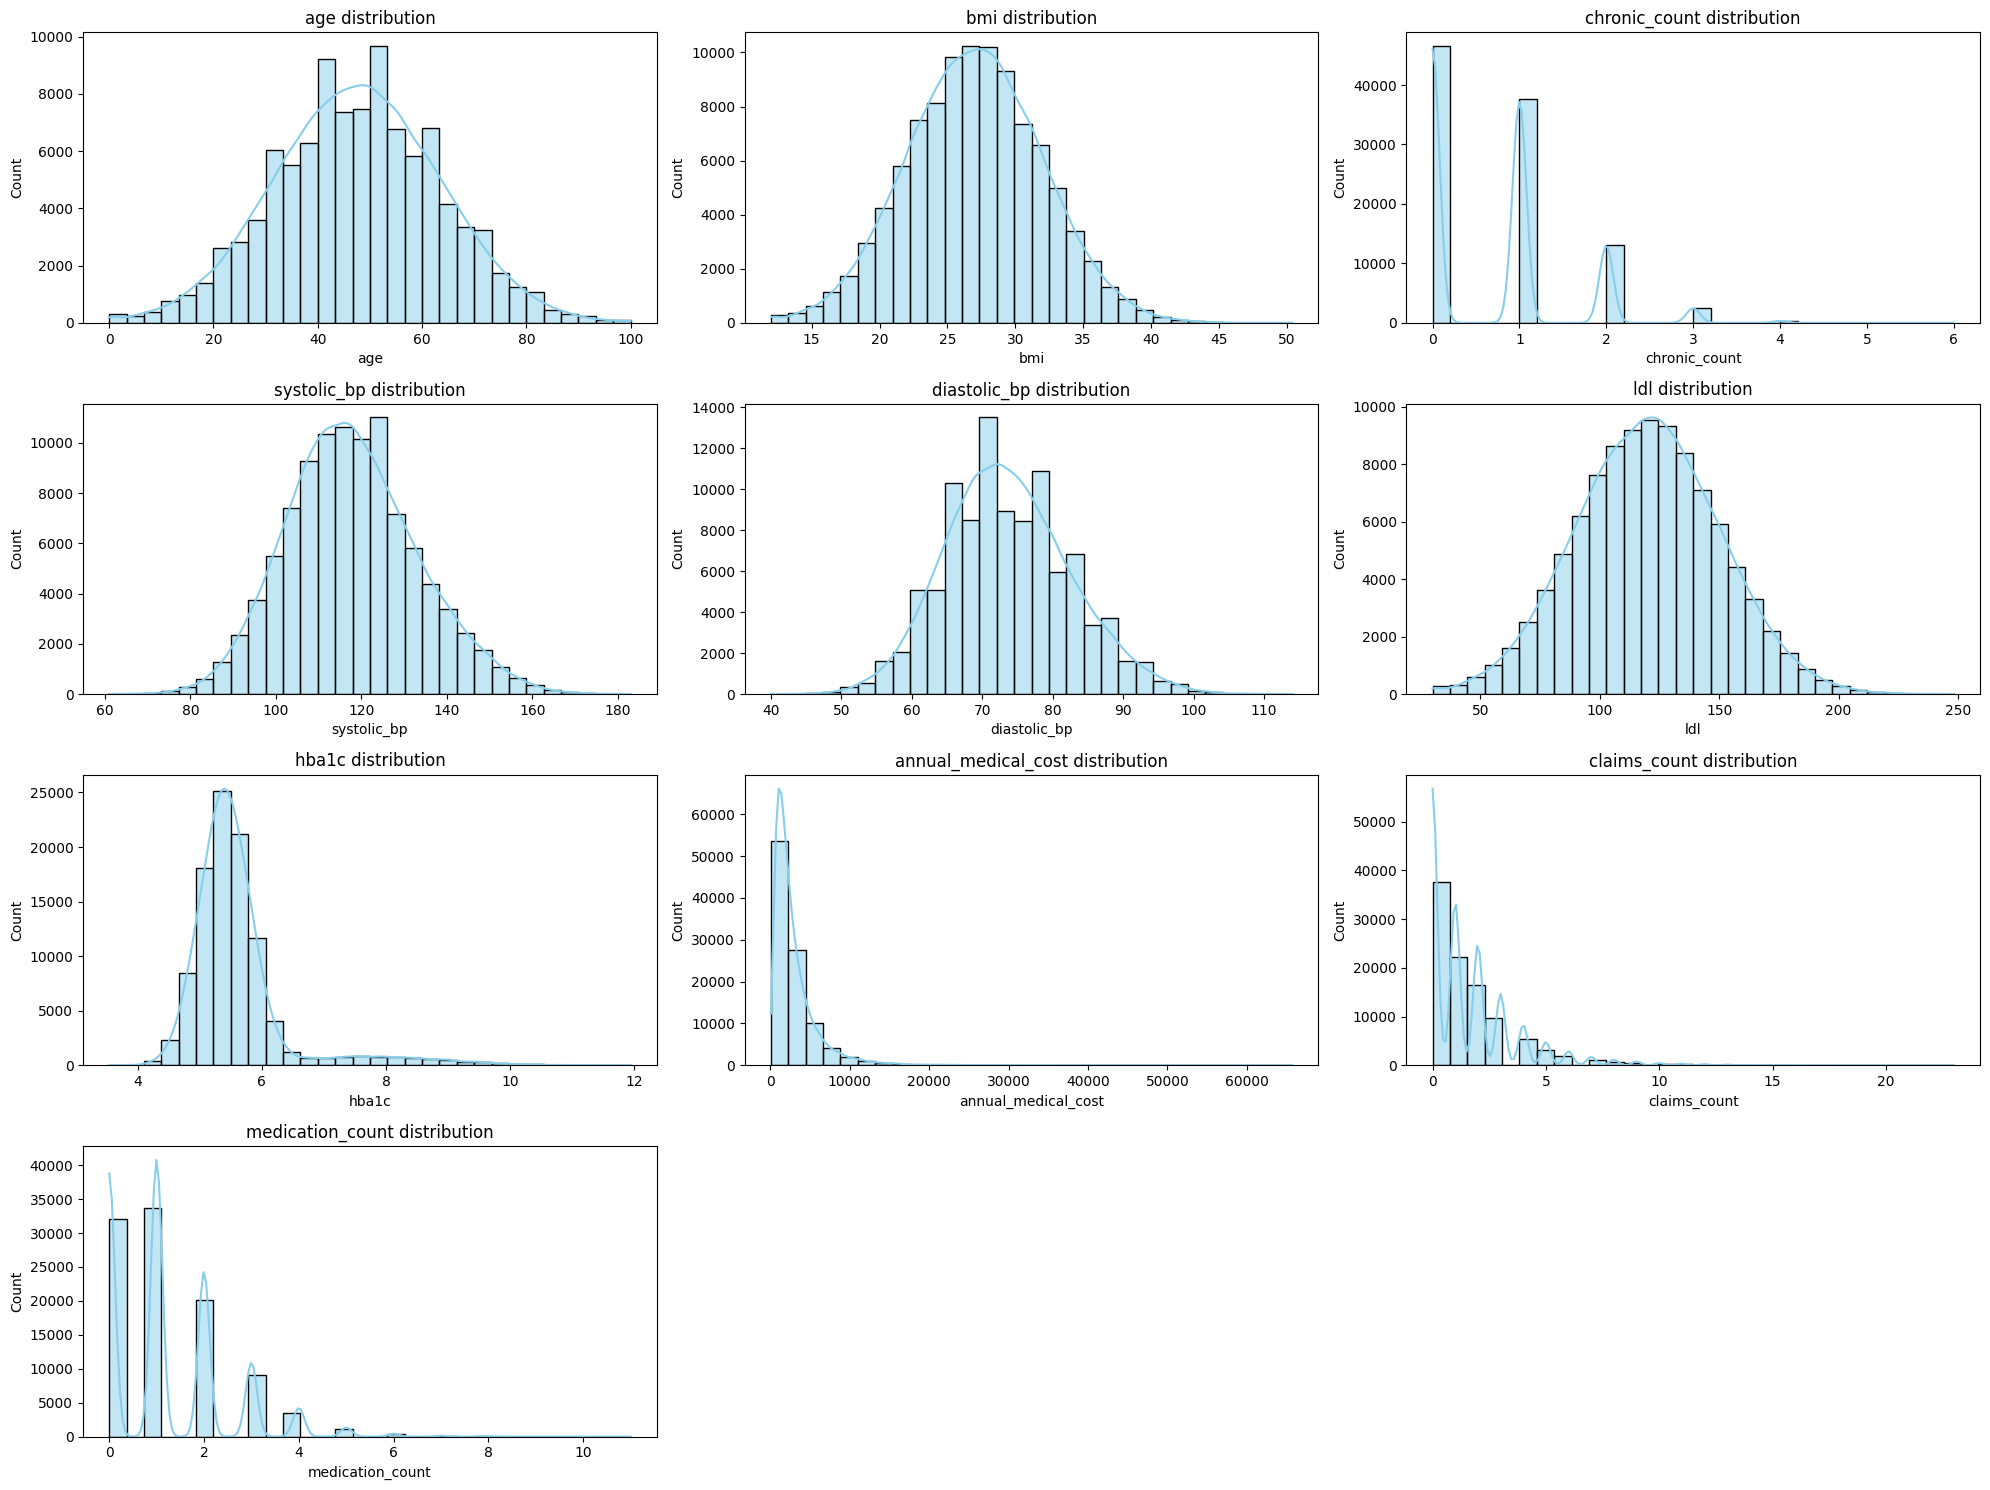

In [111]:
num_cols = ['age','bmi','chronic_count','systolic_bp','diastolic_bp','ldl','hba1c','annual_medical_cost','claims_count','medication_count']

plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.show()

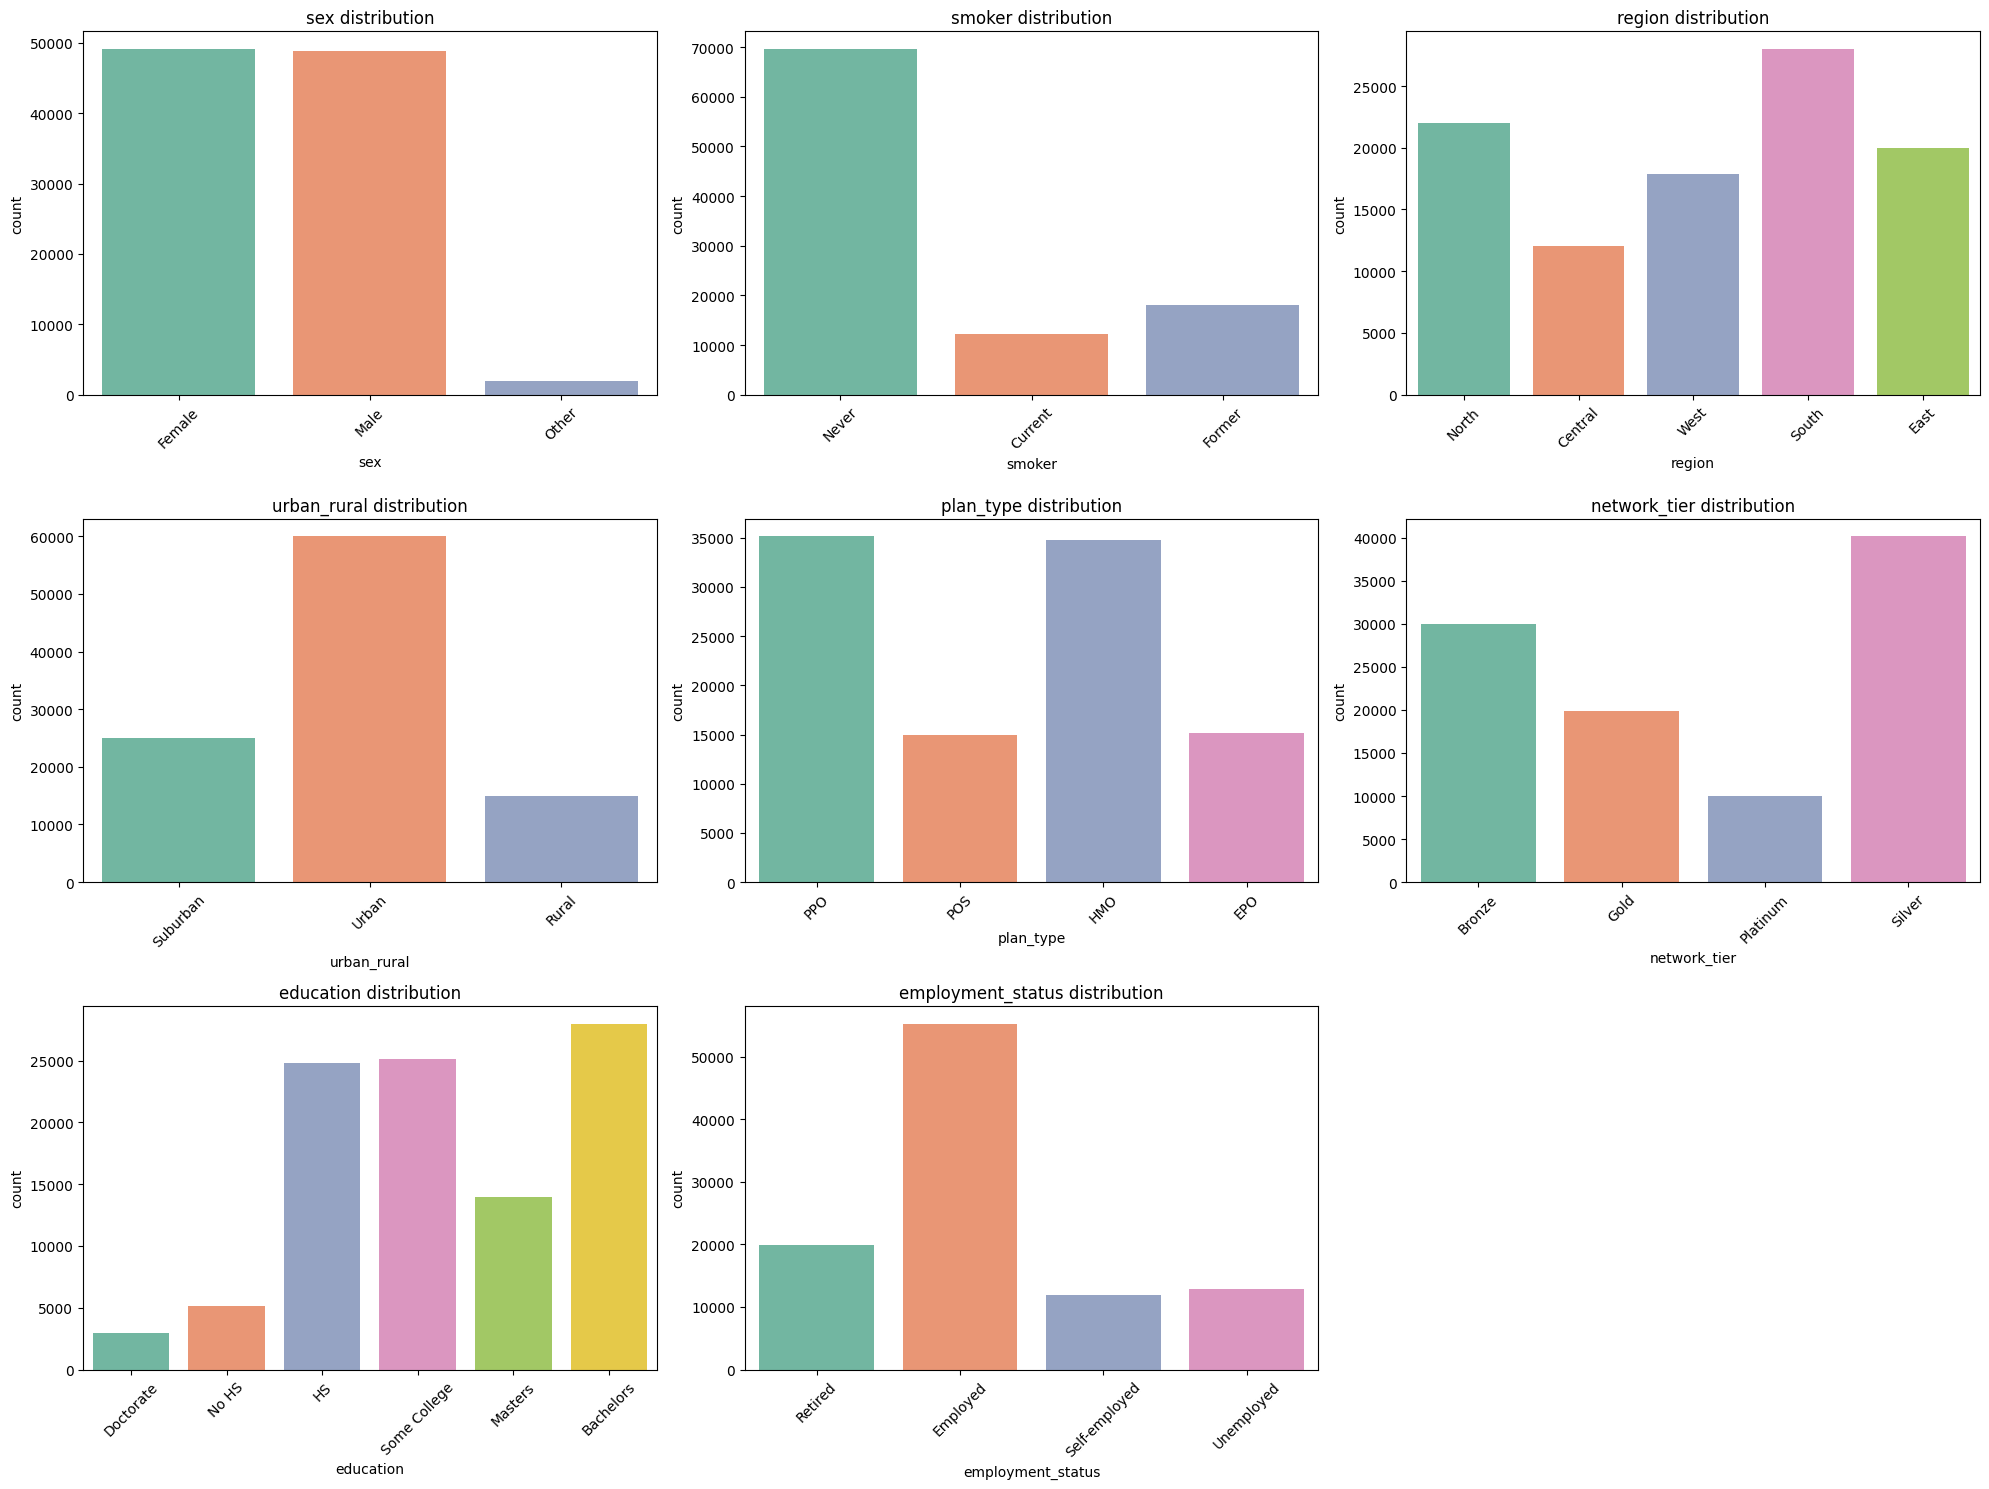

In [112]:
cat_cols = ['sex','smoker','region','urban_rural','plan_type','network_tier','education','employment_status']

plt.figure(figsize=(20,15))
for i, col in enumerate(cat_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
    plt.xticks(rotation=45)
    plt.title(f'{col} distribution')
plt.tight_layout()
plt.show()

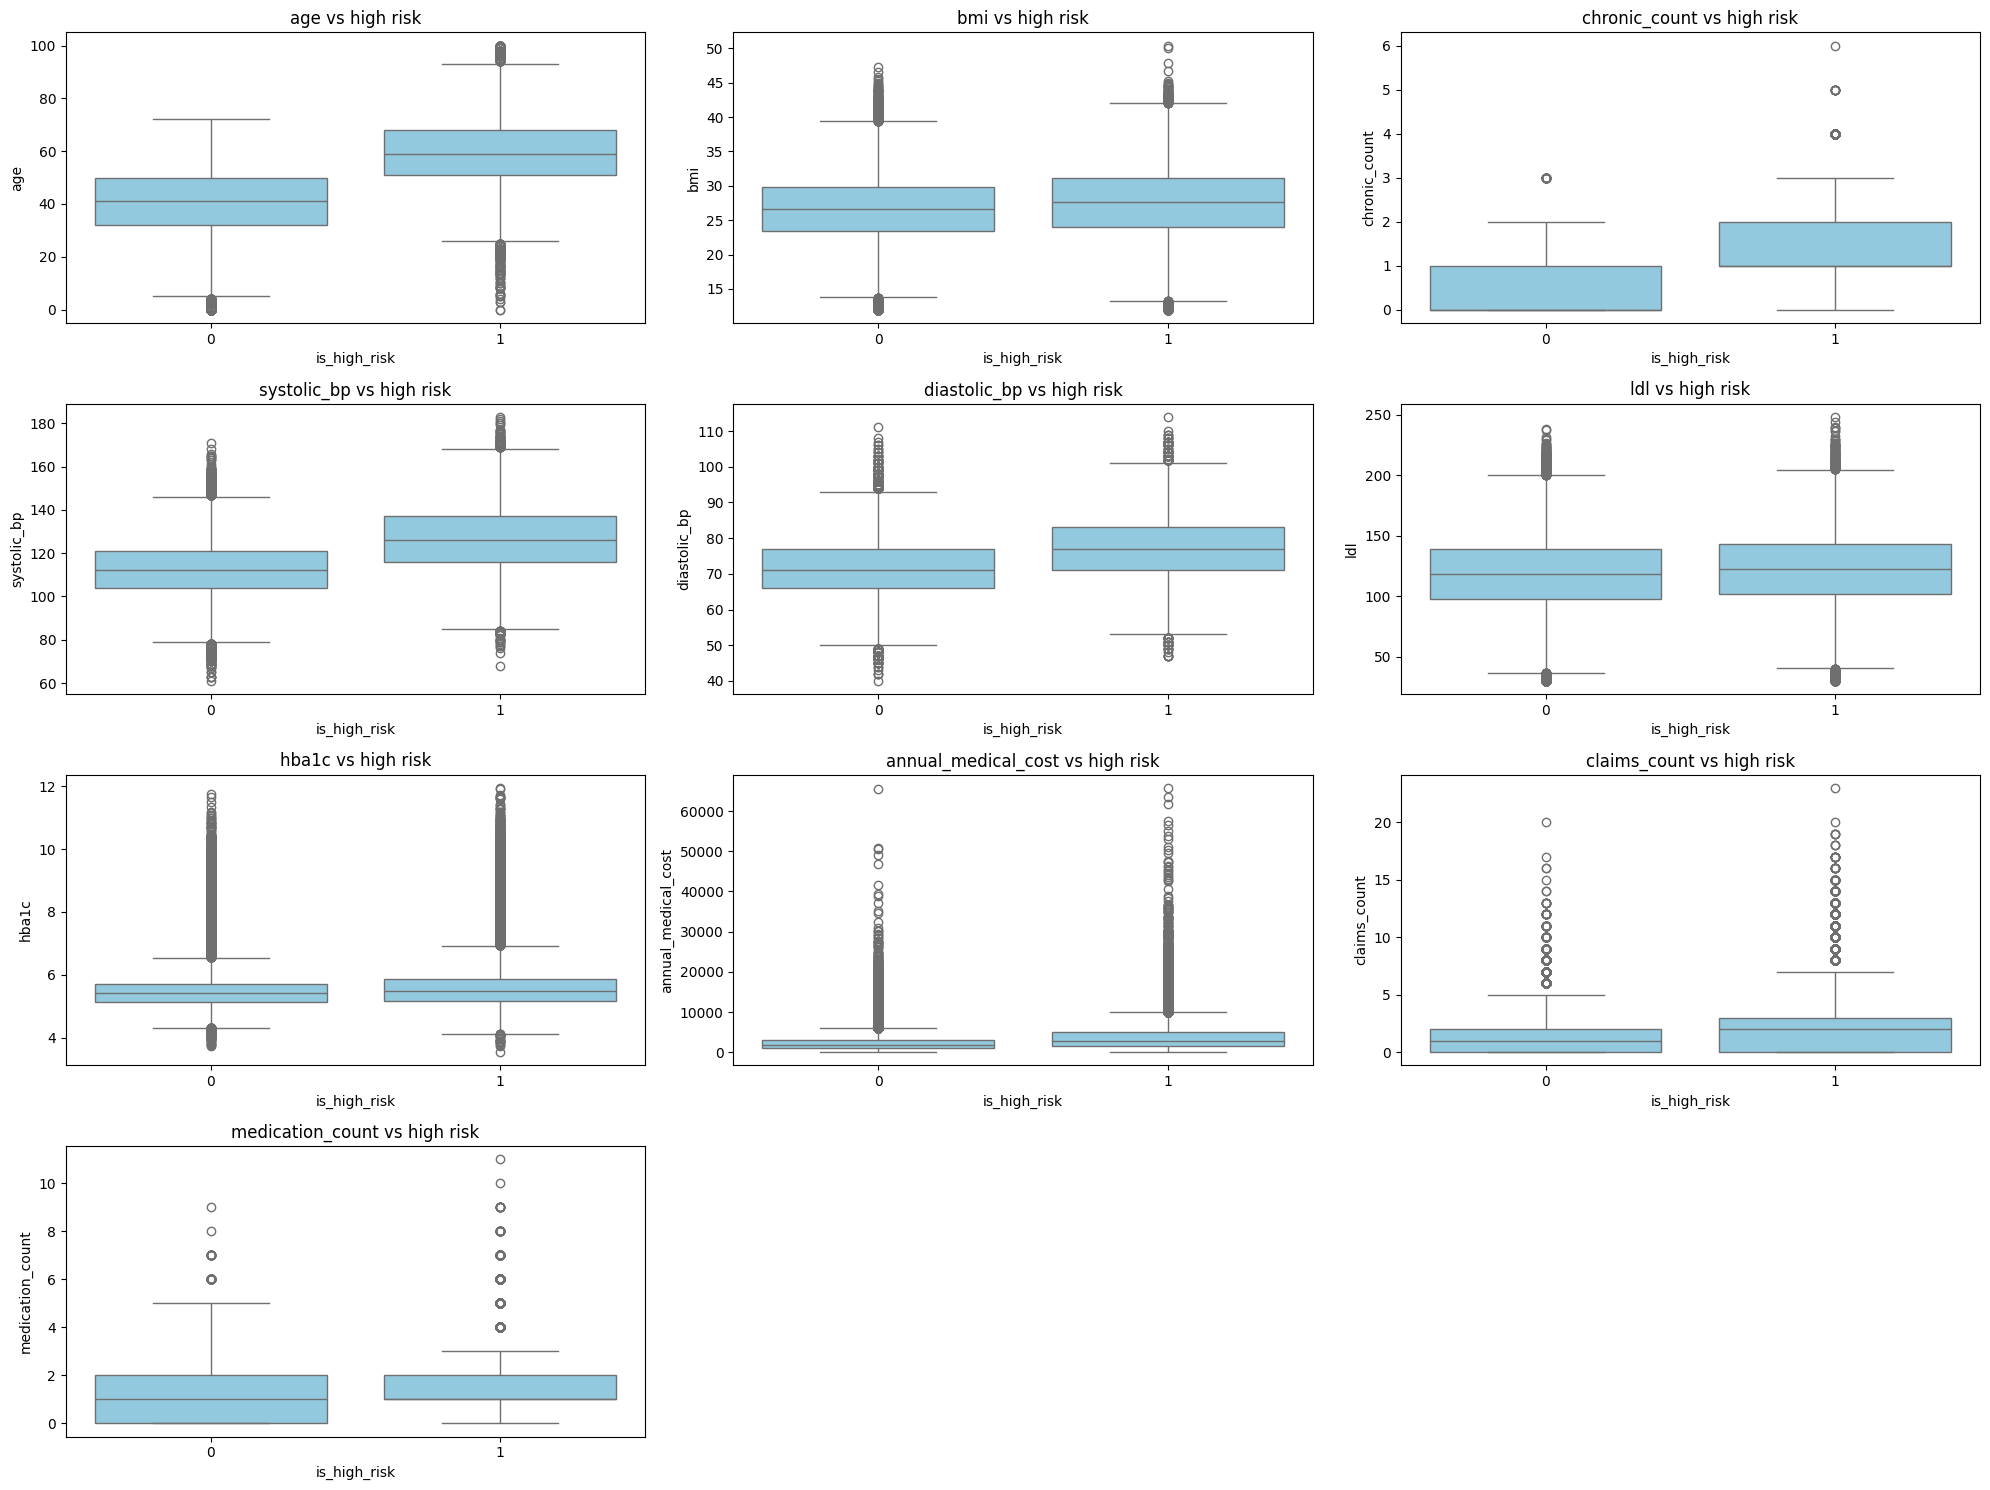

In [113]:
plt.figure(figsize=(20,15))
for i, col in enumerate(num_cols):
    plt.subplot(4,3,i+1)
    sns.boxplot(x='is_high_risk', y=col, data=df, color='skyblue')
    plt.title(f'{col} vs high risk')
plt.tight_layout()
plt.show()

In [114]:
cat_cols = [
    # Demographics & Socioeconomic
    'sex', 'region', 'urban_rural', 'education', 'marital_status', 'employment_status',
    
    # Lifestyle & Habits
    'smoker', 'alcohol_freq',
    
    # Health & Clinical
    'hypertension', 'diabetes', 'copd', 'cancer_history',
    'kidney_disease', 'liver_disease', 'arthritis', 'mental_health',

    # Insurance & Policy
    'plan_type', 'network_tier', 'provider_quality'
]

In [115]:
for col in cat_cols:
    table = pd.crosstab(df[col], df['is_high_risk'])
    chi2, p, _, _ = chi2_contingency(table)
    print(f"{col}: p-value={p:.4f}")

sex: p-value=0.1316
region: p-value=0.3299
urban_rural: p-value=0.3170
education: p-value=0.0079
marital_status: p-value=0.1841
employment_status: p-value=0.5495
smoker: p-value=0.0000
alcohol_freq: p-value=0.0840
hypertension: p-value=0.0000
diabetes: p-value=0.0000
copd: p-value=0.0000
cancer_history: p-value=0.0000
kidney_disease: p-value=0.0000
liver_disease: p-value=0.0000
arthritis: p-value=0.0000
mental_health: p-value=0.0000
plan_type: p-value=0.3811
network_tier: p-value=0.2039
provider_quality: p-value=0.7356


### Categorical Feature Selection for Machine Learning Model

We performed a Chi-squared test to assess the association between categorical variables and the target variable `is_high_risk`. Variables with p-values below 0.05 were considered significantly associated with the target and will be included in the model.  

**Significant categorical variables selected for modeling:**  
- `education`  
- `smoker`  
- `hypertension`  
- `diabetes`  
- `copd`  
- `cancer_history`  
- `kidney_disease`  
- `liver_disease`  
- `arthritis`  
- `mental_health`  

Variables such as `sex`, `region`, `urban_rural`, `marital_status`, `employment_status`, `alcohol_freq`, `plan_type`, `network_tier`, and `provider_quality` showed no significant association (p > 0.05) and will not be used as categorical features in the model.


In [118]:
relevant_cat_cols = [
    'education', 'smoker', 'hypertension', 'diabetes', 'copd',
    'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health'
]

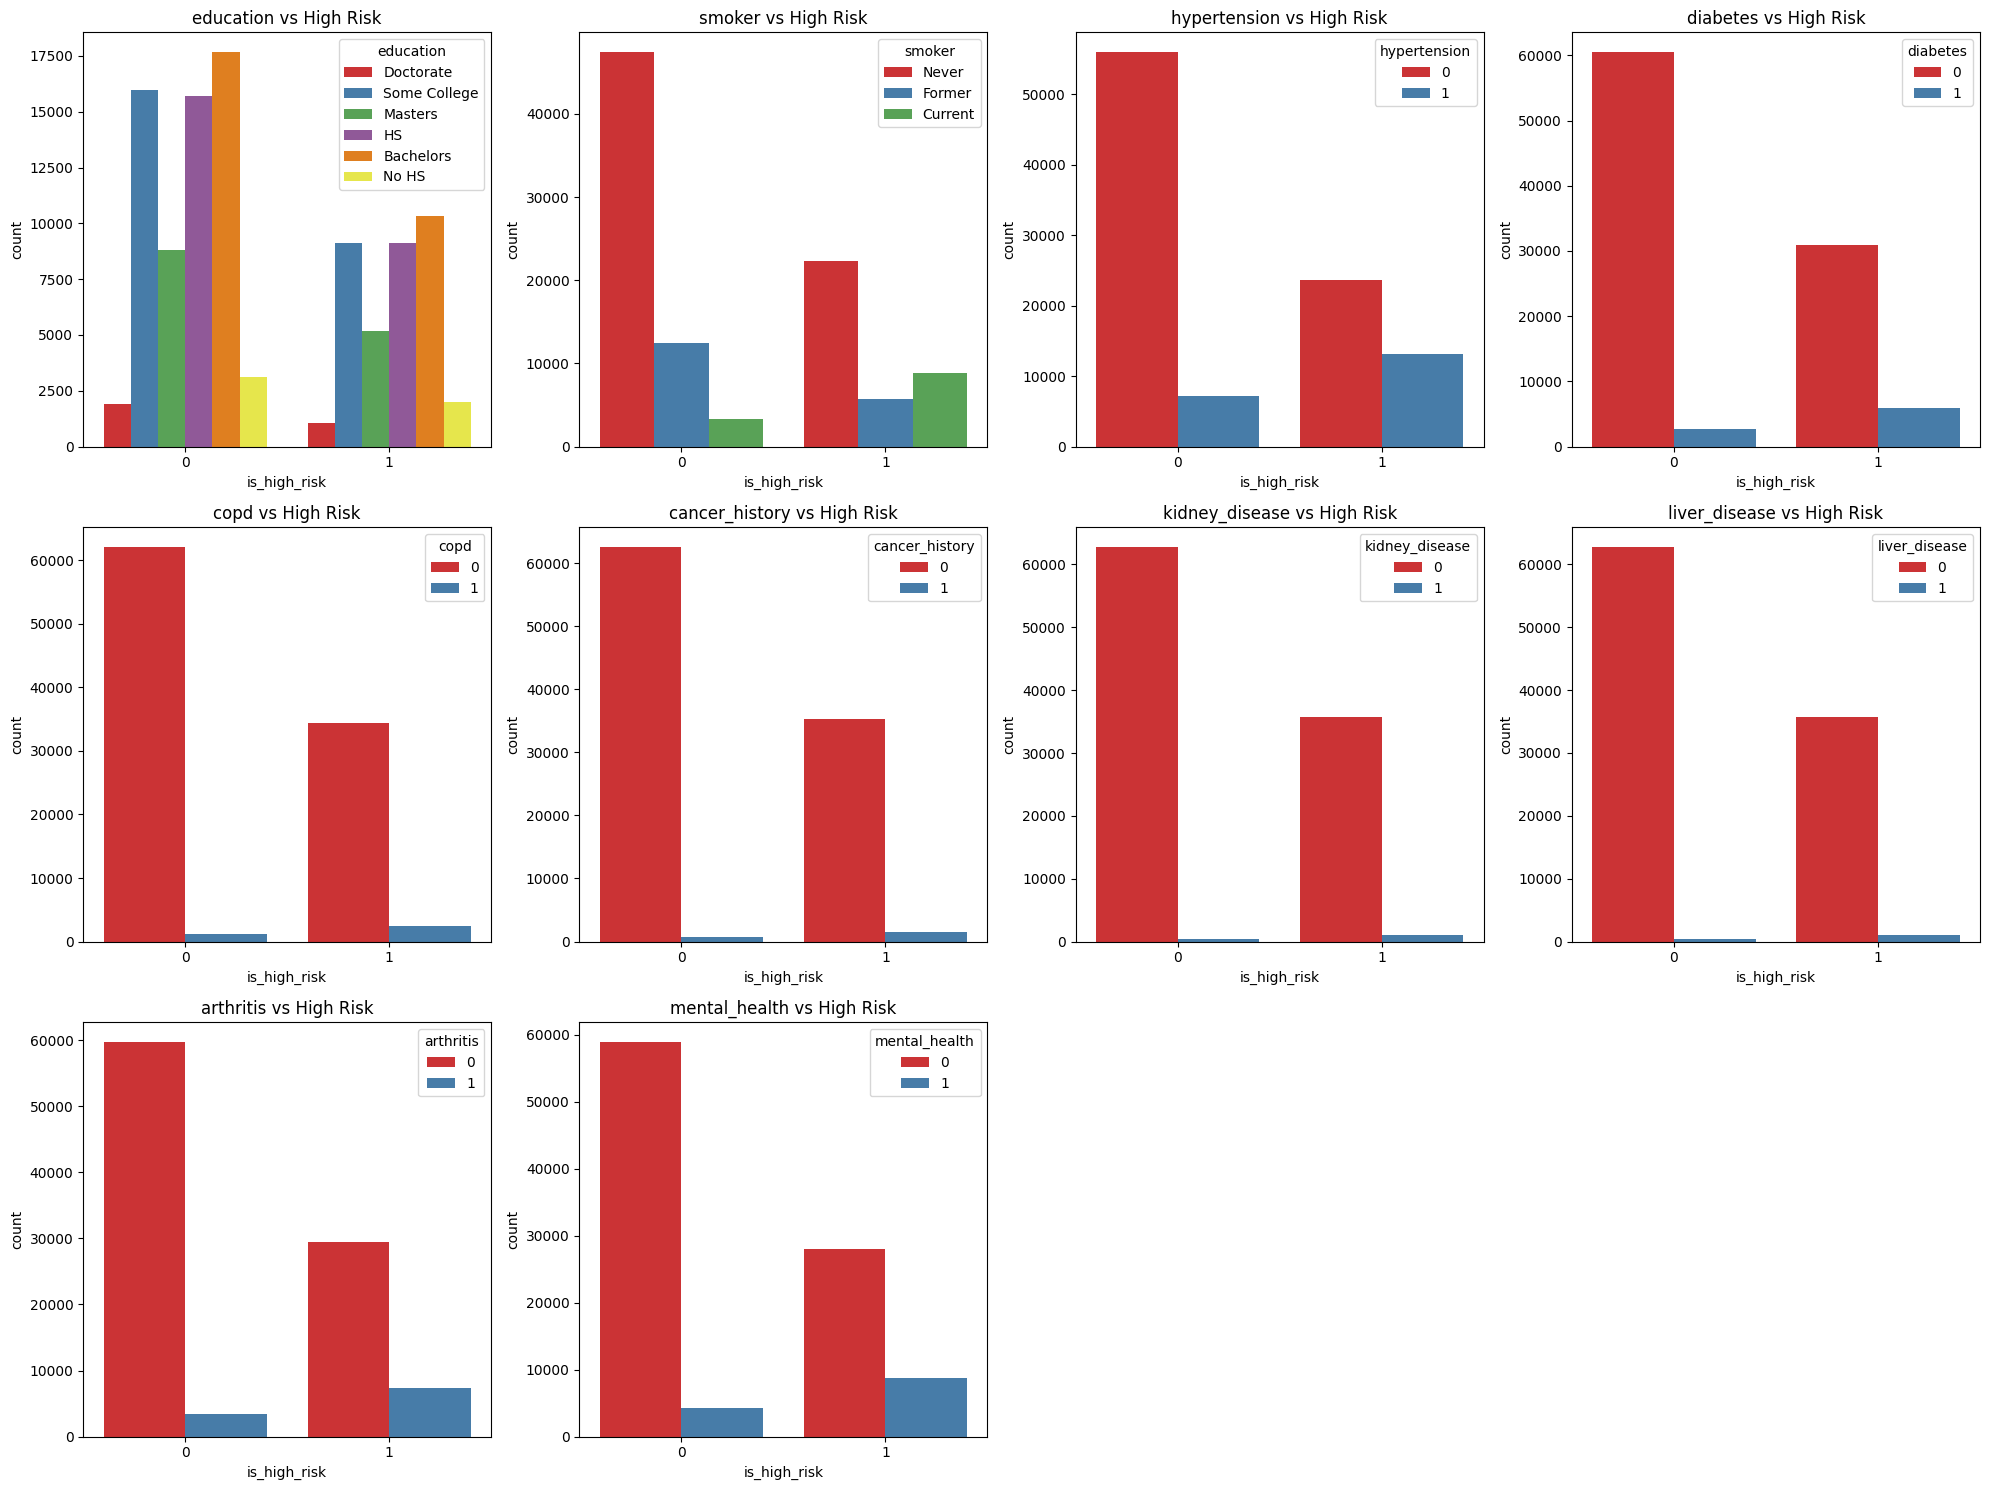

In [120]:
plt.figure(figsize=(20,15))

for i, col in enumerate(relevant_cat_cols):
    plt.subplot(3,4,i+1)
    sns.countplot(x='is_high_risk', hue=col, data=df, palette='Set1')
    plt.title(f'{col} vs High Risk')

plt.tight_layout()
plt.show()

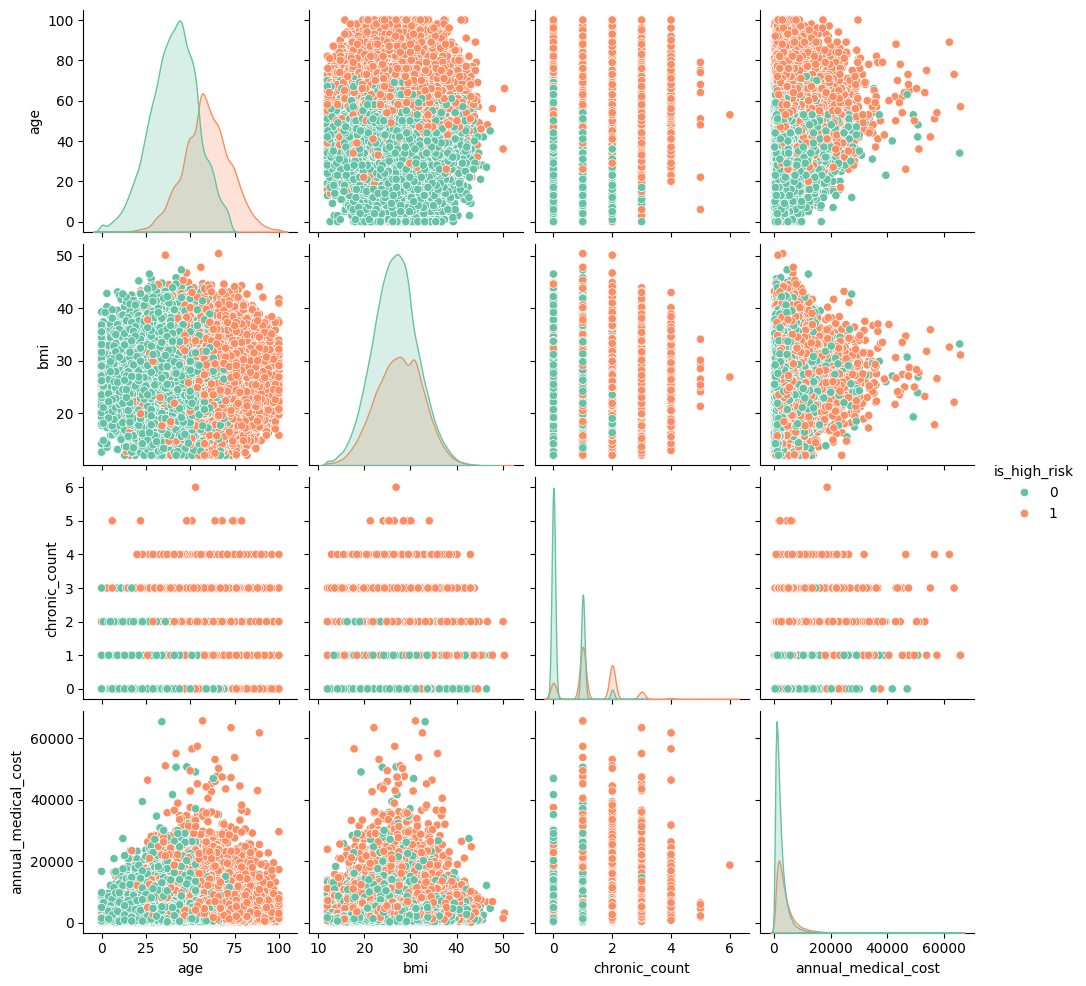

In [121]:
selected = ['age','bmi','chronic_count','annual_medical_cost','is_high_risk']
sns.pairplot(df[selected], hue='is_high_risk', palette='Set2')
plt.show()

In [122]:
for col in num_cols:
    groups = [group[col].values for name, group in df.groupby('is_high_risk')]
    stat, p = kruskal(*groups)
    print(f"{col}: p-value={p:.4f}")

age: p-value=0.0000
bmi: p-value=0.0000
chronic_count: p-value=0.0000
systolic_bp: p-value=0.0000
diastolic_bp: p-value=0.0000
ldl: p-value=0.0000
hba1c: p-value=0.0000
annual_medical_cost: p-value=0.0000
claims_count: p-value=0.0000
medication_count: p-value=0.0000


### Numerical Feature Selection for Machine Learning Model

We used the Kruskal-Wallis test to evaluate the association between numerical variables and the target `is_high_risk`. All tested variables showed significant differences between high-risk and low-risk groups (p < 0.05) and will be included as features in the model.

**Selected numerical variables:**  
- `age`  
- `bmi`  
- `chronic_count`  
- `systolic_bp`  
- `diastolic_bp`  
- `ldl`  
- `hba1c`  
- `annual_medical_cost`  
- `claims_count`  
- `medication_count`

C:\Users\sebas\AppData\Local\Temp\ipykernel_20644\1404463851.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


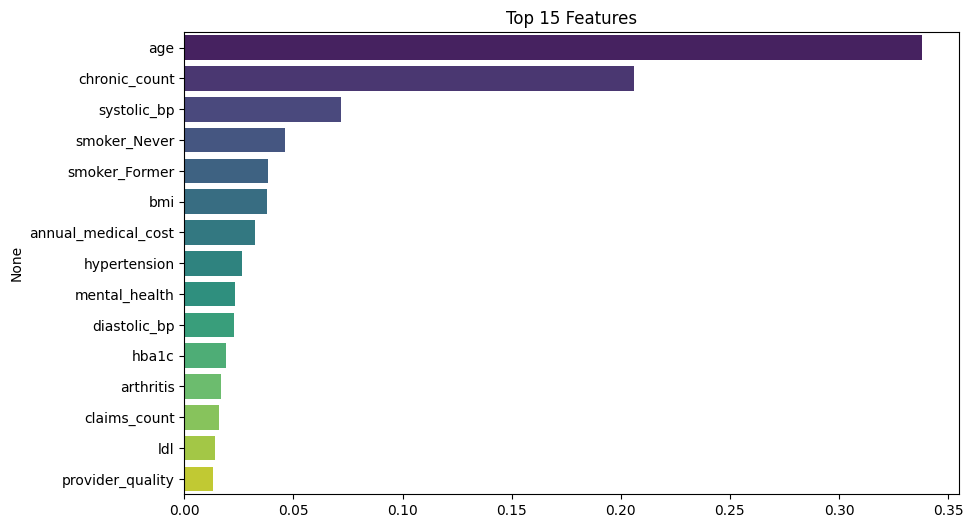

In [123]:
X = df[num_cols + cat_cols].copy()

X = pd.get_dummies(X, drop_first=True)
y = LabelEncoder().fit_transform(df['is_high_risk'])

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Top 15 Features")
plt.show()

### Feature Selection Confirmation

The statistical tests (Chi-squared for categorical and Kruskal-Wallis for numerical features) identified the most relevant variables for `is_high_risk`.  
Training a Random Forest classifier and examining feature importances confirms that these variables are also the most predictive, supporting our initial selection.

In [124]:
features = [ 'age','sex', 'region', 'urban_rural', 'income', 'education',
    'marital_status', 'employment_status', 'household_size', 'dependents',
    'bmi', 'smoker', 'visits_last_year', 'hospitalizations_last_3yrs',
    'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
    'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible',
    'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count', 'had_major_procedure'
]

# Models 

In [ ]:
X=df[features]
y= df['risk_score']
y = (y > 0.5).astype(int) #for two classes
# y = pd.qcut(y, q=3, labels=['low', 'medium', 'high']) #for tree classes

print(y.value_counts())

# var cat
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
# normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
len(X_train_scaled)

In [ ]:
y_train

75220    medium
48955       low
44966      high
13568       low
92727       low
          ...  
6265        low
54886    medium
76820       low
860        high
15795    medium
Name: health_risk_category, Length: 80000, dtype: object

In [ ]:
y.isna().sum()  #checking if there is NaN

0

## RandomizedSearchCV ##

In [125]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [126]:
def randomized_search(x_train, y_train, clf, param_dist, n_iter=20):
    random_search = RandomizedSearchCV(
        clf,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=5,
        scoring='accuracy',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    random_search.fit(x_train, y_train)
    print("Best parameters found:", random_search.best_params_)
    
    return random_search.best_estimator_

In [127]:
clf = RandomForestClassifier(random_state=42)

In [ ]:
"""
params_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}
"""

In [128]:
params_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10]
}

In [129]:
best_rf_random = randomized_search(X_train, y_train, clf, params_rf)

C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=20. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters found: {'n_estimators': 300, 'max_depth': None}


              precision    recall  f1-score   support

        high       0.55      0.45      0.49      3359
         low       0.69      0.94      0.80     12125
      medium       0.46      0.08      0.14      4516

    accuracy                           0.67     20000
   macro avg       0.57      0.49      0.48     20000
weighted avg       0.62      0.67      0.60     20000



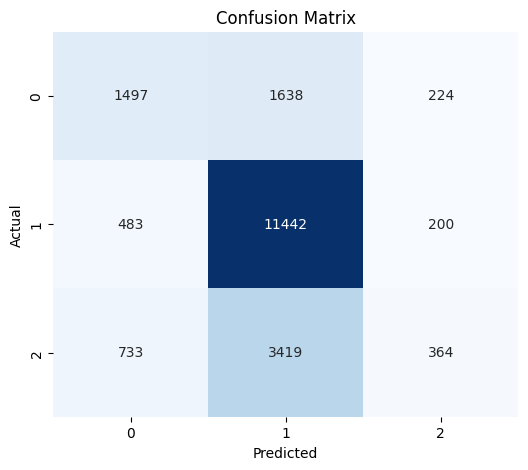

In [130]:
evaluate_model(best_rf_random, X_test, y_test)

### PyTorch MLP

In [ ]:
y= df['risk_score']
y = pd.qcut(y, q=3, labels=['low', 'medium', 'high']) #for tree classes

In [132]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)

In [133]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [134]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
y_encoded

array([2, 0, 0, ..., 2, 2, 1])

In [136]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [137]:
full_train_dataset = TabularDataset(X_train_scaled, y_train)
test_dataset = TabularDataset(X_test_scaled, y_test)

In [138]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [139]:

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [140]:
model = MLP(input_dim, num_classes)

In [141]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

In [142]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1/30 | Train Loss: 0.2137 | Val Loss: 0.1577
Epoch 2/30 | Train Loss: 0.1523 | Val Loss: 0.1281
Epoch 3/30 | Train Loss: 0.1363 | Val Loss: 0.1253
Epoch 4/30 | Train Loss: 0.1321 | Val Loss: 0.1177
Epoch 5/30 | Train Loss: 0.1225 | Val Loss: 0.1294
Epoch 6/30 | Train Loss: 0.1228 | Val Loss: 0.1276
Epoch 7/30 | Train Loss: 0.1137 | Val Loss: 0.1140
Epoch 8/30 | Train Loss: 0.1142 | Val Loss: 0.1414
Epoch 9/30 | Train Loss: 0.1144 | Val Loss: 0.1078
Epoch 10/30 | Train Loss: 0.1157 | Val Loss: 0.1331
Epoch 11/30 | Train Loss: 0.1122 | Val Loss: 0.1506
Epoch 12/30 | Train Loss: 0.1096 | Val Loss: 0.1403
Epoch 13/30 | Train Loss: 0.1112 | Val Loss: 0.1351
Epoch 14/30 | Train Loss: 0.1114 | Val Loss: 0.1319
Epoch 15/30 | Train Loss: 0.1098 | Val Loss: 0.1398
Epoch 16/30 | Train Loss: 0.1066 | Val Loss: 0.1784
Epoch 17/30 | Train Loss: 0.1070 | Val Loss: 0.1426
Epoch 18/30 | Train Loss: 0.1000 | Val Loss: 0.1161
Epoch 19/30 | Train Loss: 0.1131 | Val Loss: 0.1351
Epoch 20/30 | Train L

In [143]:
train_losses = []
train_accuracies = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # accuracy del batch
        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")

Epoch 1: Loss=0.0871, Acc=0.9721
Epoch 2: Loss=0.1092, Acc=0.9649
Epoch 3: Loss=0.1055, Acc=0.9659
Epoch 4: Loss=0.0808, Acc=0.9740
Epoch 5: Loss=0.0797, Acc=0.9746
Epoch 6: Loss=0.1018, Acc=0.9672
Epoch 7: Loss=0.1026, Acc=0.9683
Epoch 8: Loss=0.1677, Acc=0.9464
Epoch 9: Loss=0.4469, Acc=0.8387
Epoch 10: Loss=1.0997, Acc=0.4348
Epoch 11: Loss=1.1026, Acc=0.3687
Epoch 12: Loss=1.0882, Acc=0.3480
Epoch 13: Loss=1.0996, Acc=0.3383
Epoch 14: Loss=1.1034, Acc=0.3397
Epoch 15: Loss=1.0616, Acc=0.3899
Epoch 16: Loss=1.0744, Acc=0.3621
Epoch 17: Loss=1.0856, Acc=0.3591
Epoch 18: Loss=1.1009, Acc=0.3379
Epoch 19: Loss=1.1009, Acc=0.3397
Epoch 20: Loss=1.1009, Acc=0.3398
Epoch 21: Loss=1.1005, Acc=0.3406
Epoch 22: Loss=1.1010, Acc=0.3389
Epoch 23: Loss=1.1008, Acc=0.3394
Epoch 24: Loss=1.1006, Acc=0.3361
Epoch 25: Loss=1.1006, Acc=0.3384
Epoch 26: Loss=1.1004, Acc=0.3428
Epoch 27: Loss=1.1004, Acc=0.3407
Epoch 28: Loss=1.1011, Acc=0.3368
Epoch 29: Loss=1.1009, Acc=0.3394
Epoch 30: Loss=1.1004, 

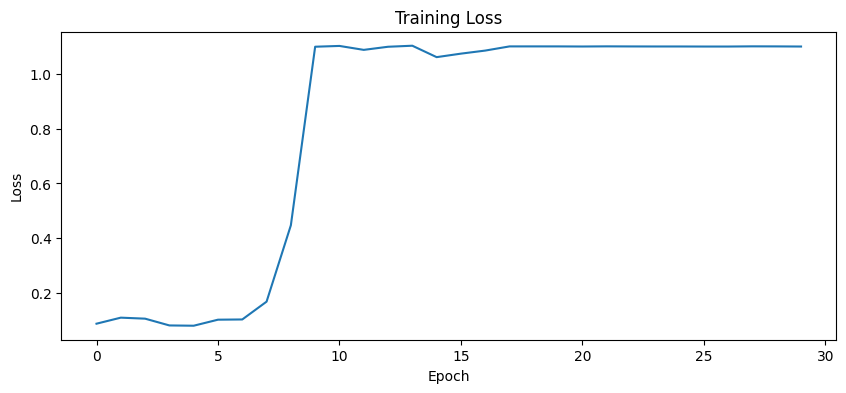

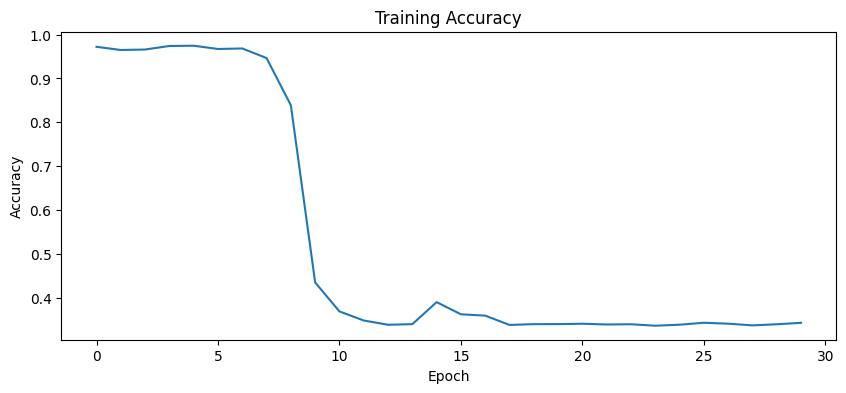

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

              precision    recall  f1-score   support

           0       0.33      1.00      0.49      6524
           1       1.00      0.00      0.00      7008
           2       0.00      0.00      0.00      6468

    accuracy                           0.33     20000
   macro avg       0.44      0.33      0.16     20000
weighted avg       0.46      0.33      0.16     20000



C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sebas\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\metrics\_clas

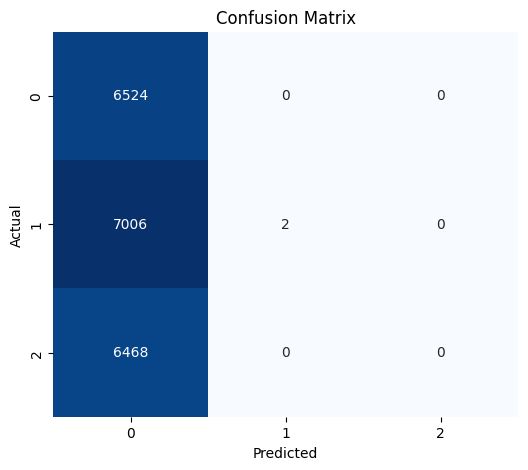

In [145]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [146]:

def create_model(input_dim, num_classes, n_layers, n_neurons):
    layers = []
    in_features = input_dim

    for _ in range(n_layers):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.ReLU())
        in_features = n_neurons

    layers.append(nn.Linear(in_features, num_classes))
    return nn.Sequential(*layers)


def objective(trial):

    # hiperparámetros a tunear
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    n_neurons = trial.suggest_int("n_neurons", 16, 256)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_loader_hp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model_hp = create_model(input_dim, num_classes, n_layers, n_neurons)
    optimizer = torch.optim.Adam(model_hp.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model_hp.train()
    for epoch in range(5):  # entrenamos poco para no tardar horas
        for X_batch, y_batch in train_loader_hp:
            optimizer.zero_grad()
            outputs = model_hp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # evaluación rápida
    model_hp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            outputs = model_hp(Xb)
            _, preds = outputs.max(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    accuracy = correct / total
    return accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2025-12-06 21:04:40,568] A new study created in memory with name: no-name-1b1b7216-e09e-44cd-b0df-23048ea67416
[I 2025-12-06 21:04:52,244] Trial 0 finished with value: 0.9486 and parameters: {'lr': 0.025434591077542867, 'n_layers': 3, 'n_neurons': 65, 'batch_size': 128}. Best is trial 0 with value: 0.9486.
[I 2025-12-06 21:05:12,639] Trial 1 finished with value: 0.9512 and parameters: {'lr': 0.004987617232548006, 'n_layers': 1, 'n_neurons': 157, 'batch_size': 32}. Best is trial 1 with value: 0.9512.
[I 2025-12-06 21:05:27,195] Trial 2 finished with value: 0.9393 and parameters: {'lr': 0.0002364492367552338, 'n_layers': 4, 'n_neurons': 108, 'batch_size': 128}. Best is trial 1 with value: 0.9512.
[I 2025-12-06 21:05:42,448] Trial 3 finished with value: 0.95 and parameters: {'lr': 0.0011257680661374682, 'n_layers': 1, 'n_neurons': 149, 'batch_size': 64}. Best is trial 1 with value: 0.9512.
[I 2025-12-06 21:05:56,040] Trial 4 finished with value: 0.96 and parameters: {'lr': 0.0092965198

In [147]:
print("Best accuracy:", study.best_value)
print("Best params:", study.best_params)

Best accuracy: 0.9657
Best params: {'lr': 0.004380102134366655, 'n_layers': 3, 'n_neurons': 21, 'batch_size': 32}


In [148]:
best = study.best_params

final_model = create_model(
    input_dim,
    num_classes,
    best["n_layers"],
    best["n_neurons"]
)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])

In [149]:
optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])
criterion = nn.CrossEntropyLoss()

In [150]:
final_train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)

In [152]:
num_epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    final_model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in final_train_loader:
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(final_train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")


Epoch 1: Loss=0.0812, Acc=0.9654
Epoch 2: Loss=0.0747, Acc=0.9687
Epoch 3: Loss=0.0708, Acc=0.9712
Epoch 4: Loss=0.0689, Acc=0.9724
Epoch 5: Loss=0.0643, Acc=0.9742
Epoch 6: Loss=0.0612, Acc=0.9750
Epoch 7: Loss=0.0585, Acc=0.9761
Epoch 8: Loss=0.0562, Acc=0.9773
Epoch 9: Loss=0.0553, Acc=0.9776
Epoch 10: Loss=0.0531, Acc=0.9785
Epoch 11: Loss=0.0497, Acc=0.9803
Epoch 12: Loss=0.0476, Acc=0.9801
Epoch 13: Loss=0.0477, Acc=0.9804
Epoch 14: Loss=0.0453, Acc=0.9815
Epoch 15: Loss=0.0452, Acc=0.9825
Epoch 16: Loss=0.0438, Acc=0.9821
Epoch 17: Loss=0.0432, Acc=0.9827
Epoch 18: Loss=0.0414, Acc=0.9833
Epoch 19: Loss=0.0398, Acc=0.9839
Epoch 20: Loss=0.0381, Acc=0.9850
Epoch 21: Loss=0.0389, Acc=0.9843
Epoch 22: Loss=0.0368, Acc=0.9855
Epoch 23: Loss=0.0366, Acc=0.9858
Epoch 24: Loss=0.0362, Acc=0.9859
Epoch 25: Loss=0.0350, Acc=0.9859
Epoch 26: Loss=0.0352, Acc=0.9858
Epoch 27: Loss=0.0339, Acc=0.9871
Epoch 28: Loss=0.0328, Acc=0.9864
Epoch 29: Loss=0.0323, Acc=0.9874
Epoch 30: Loss=0.0352, 

In [153]:
final_model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        _, preds = outputs.max(1)
        all_preds.append(preds)

all_preds = torch.cat(all_preds)

In [154]:
print(classification_report(y_test, all_preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6524
           1       0.99      0.99      0.99      7008
           2       0.98      0.98      0.98      6468

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



### PyTorch MLP for 2 classes

In [156]:
y= df['risk_score']
y = (y > 0.5).astype(int)

In [157]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X = pd.get_dummies(X, drop_first=True)

In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [159]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [160]:
y_encoded

array([1, 1, 1, ..., 0, 1, 0], dtype=int64)

In [161]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [162]:
full_train_dataset = TabularDataset(X_train_scaled, y_train)
test_dataset = TabularDataset(X_test_scaled, y_test)

In [163]:
val_size = int(0.2 * len(full_train_dataset))
train_size = len(full_train_dataset) - val_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [164]:
input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [165]:
model = MLP(input_dim, num_classes)

In [166]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9)

In [167]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 1/30 | Train Loss: 0.1060 | Val Loss: 0.0811
Epoch 2/30 | Train Loss: 0.0645 | Val Loss: 0.0636
Epoch 3/30 | Train Loss: 0.0550 | Val Loss: 0.0585
Epoch 4/30 | Train Loss: 0.0480 | Val Loss: 0.0615
Epoch 5/30 | Train Loss: 0.0442 | Val Loss: 0.0541
Epoch 6/30 | Train Loss: 0.0415 | Val Loss: 0.0502
Epoch 7/30 | Train Loss: 0.0396 | Val Loss: 0.0453
Epoch 8/30 | Train Loss: 0.0365 | Val Loss: 0.0454
Epoch 9/30 | Train Loss: 0.0358 | Val Loss: 0.0590
Epoch 10/30 | Train Loss: 0.0338 | Val Loss: 0.0489
Epoch 11/30 | Train Loss: 0.0330 | Val Loss: 0.0487
Epoch 12/30 | Train Loss: 0.0314 | Val Loss: 0.0421
Epoch 13/30 | Train Loss: 0.0300 | Val Loss: 0.0385
Epoch 14/30 | Train Loss: 0.0283 | Val Loss: 0.0435
Epoch 15/30 | Train Loss: 0.0274 | Val Loss: 0.0374
Epoch 16/30 | Train Loss: 0.0270 | Val Loss: 0.0443
Epoch 17/30 | Train Loss: 0.0254 | Val Loss: 0.0438
Epoch 18/30 | Train Loss: 0.0260 | Val Loss: 0.0477
Epoch 19/30 | Train Loss: 0.0244 | Val Loss: 0.0497
Epoch 20/30 | Train L

In [168]:
train_losses = []
train_accuracies = []

for epoch in range(30):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # accuracy del batch
        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")

Epoch 1: Loss=0.0199, Acc=0.9929
Epoch 2: Loss=0.0192, Acc=0.9929
Epoch 3: Loss=0.0173, Acc=0.9935
Epoch 4: Loss=0.0170, Acc=0.9940
Epoch 5: Loss=0.0168, Acc=0.9937
Epoch 6: Loss=0.0175, Acc=0.9938
Epoch 7: Loss=0.0173, Acc=0.9939
Epoch 8: Loss=0.0169, Acc=0.9937
Epoch 9: Loss=0.0152, Acc=0.9946
Epoch 10: Loss=0.0154, Acc=0.9944
Epoch 11: Loss=0.0172, Acc=0.9940
Epoch 12: Loss=0.0177, Acc=0.9938
Epoch 13: Loss=0.0142, Acc=0.9950
Epoch 14: Loss=0.0156, Acc=0.9945
Epoch 15: Loss=0.0176, Acc=0.9940
Epoch 16: Loss=0.0147, Acc=0.9951
Epoch 17: Loss=0.0154, Acc=0.9948
Epoch 18: Loss=0.0130, Acc=0.9954
Epoch 19: Loss=0.0127, Acc=0.9959
Epoch 20: Loss=0.0135, Acc=0.9952
Epoch 21: Loss=0.0137, Acc=0.9951
Epoch 22: Loss=0.0142, Acc=0.9955
Epoch 23: Loss=0.0121, Acc=0.9955
Epoch 24: Loss=0.0142, Acc=0.9952
Epoch 25: Loss=0.0139, Acc=0.9953
Epoch 26: Loss=0.0117, Acc=0.9959
Epoch 27: Loss=0.0124, Acc=0.9959
Epoch 28: Loss=0.0110, Acc=0.9962
Epoch 29: Loss=0.0125, Acc=0.9956
Epoch 30: Loss=0.0127, 

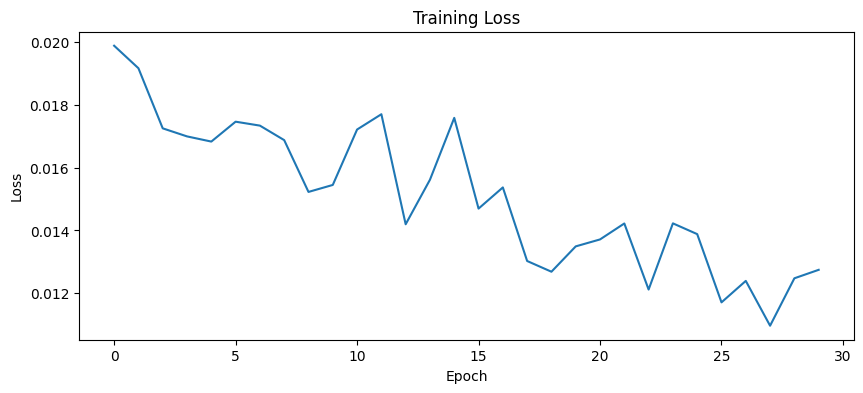

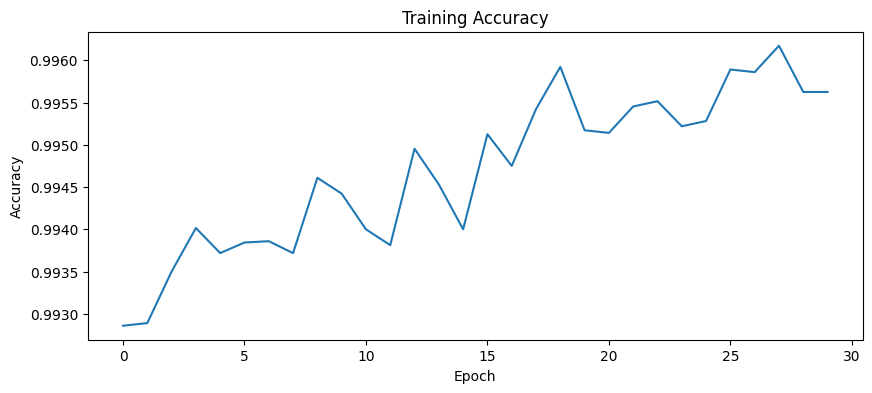

In [169]:
plt.figure(figsize=(10,4))
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      9885
           1       0.98      0.99      0.99     10115

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000



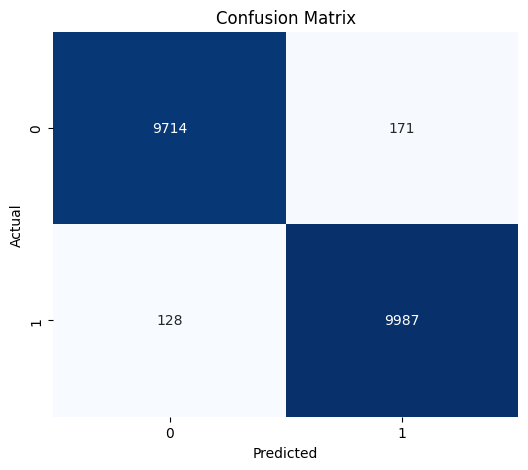

In [170]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.numpy())

print(classification_report(y_true, y_pred))

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [171]:
def create_model(input_dim, num_classes, n_layers, n_neurons):
    layers = []
    in_features = input_dim

    for _ in range(n_layers):
        layers.append(nn.Linear(in_features, n_neurons))
        layers.append(nn.ReLU())
        in_features = n_neurons

    layers.append(nn.Linear(in_features, num_classes))
    return nn.Sequential(*layers)


def objective(trial):

    # hiperparámetros a tunear
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    n_neurons = trial.suggest_int("n_neurons", 16, 256)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    train_loader_hp = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model_hp = create_model(input_dim, num_classes, n_layers, n_neurons)
    optimizer = torch.optim.Adam(model_hp.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model_hp.train()
    for epoch in range(5):  # entrenamos poco para no tardar horas
        for X_batch, y_batch in train_loader_hp:
            optimizer.zero_grad()
            outputs = model_hp(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    # evaluación rápida
    model_hp.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            outputs = model_hp(Xb)
            _, preds = outputs.max(1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    accuracy = correct / total
    return accuracy


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

[I 2025-12-06 21:22:03,811] A new study created in memory with name: no-name-72b64451-003f-42f4-8b04-ddab3ee4fbd0
[I 2025-12-06 21:22:14,753] Trial 0 finished with value: 0.9627 and parameters: {'lr': 0.00010733857940873052, 'n_layers': 3, 'n_neurons': 99, 'batch_size': 128}. Best is trial 0 with value: 0.9627.
[I 2025-12-06 21:22:40,056] Trial 1 finished with value: 0.96275 and parameters: {'lr': 0.00011652845383066762, 'n_layers': 4, 'n_neurons': 171, 'batch_size': 64}. Best is trial 1 with value: 0.96275.
[I 2025-12-06 21:22:53,833] Trial 2 finished with value: 0.966 and parameters: {'lr': 0.033008382041644656, 'n_layers': 1, 'n_neurons': 140, 'batch_size': 64}. Best is trial 2 with value: 0.966.
[I 2025-12-06 21:23:06,109] Trial 3 finished with value: 0.9772 and parameters: {'lr': 0.0060706448369183125, 'n_layers': 2, 'n_neurons': 189, 'batch_size': 128}. Best is trial 3 with value: 0.9772.
[I 2025-12-06 21:23:20,177] Trial 4 finished with value: 0.50575 and parameters: {'lr': 0.08

In [172]:
print("Best accuracy:", study.best_value)
print("Best params:", study.best_params)

Best accuracy: 0.98095
Best params: {'lr': 0.004237764276848384, 'n_layers': 2, 'n_neurons': 86, 'batch_size': 128}


In [173]:
best = study.best_params

final_model = create_model(
    input_dim,
    num_classes,
    best["n_layers"],
    best["n_neurons"]
)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])

In [174]:
optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])
criterion = nn.CrossEntropyLoss()

In [175]:
final_train_loader = DataLoader(train_dataset, batch_size=best["batch_size"], shuffle=True)

In [176]:
num_epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    final_model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in final_train_loader:
        optimizer.zero_grad()
        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        _, preds = outputs.max(1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_losses.append(epoch_loss / len(final_train_loader))
    train_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.4f}, Acc={train_accuracies[-1]:.4f}")

Epoch 1: Loss=0.1136, Acc=0.9498
Epoch 2: Loss=0.0673, Acc=0.9711
Epoch 3: Loss=0.0585, Acc=0.9747
Epoch 4: Loss=0.0522, Acc=0.9782
Epoch 5: Loss=0.0421, Acc=0.9825
Epoch 6: Loss=0.0382, Acc=0.9840
Epoch 7: Loss=0.0328, Acc=0.9864
Epoch 8: Loss=0.0288, Acc=0.9881
Epoch 9: Loss=0.0287, Acc=0.9886
Epoch 10: Loss=0.0247, Acc=0.9900
Epoch 11: Loss=0.0241, Acc=0.9905
Epoch 12: Loss=0.0235, Acc=0.9906
Epoch 13: Loss=0.0213, Acc=0.9919
Epoch 14: Loss=0.0207, Acc=0.9918
Epoch 15: Loss=0.0205, Acc=0.9918
Epoch 16: Loss=0.0173, Acc=0.9934
Epoch 17: Loss=0.0167, Acc=0.9934
Epoch 18: Loss=0.0185, Acc=0.9930
Epoch 19: Loss=0.0168, Acc=0.9936
Epoch 20: Loss=0.0145, Acc=0.9941
Epoch 21: Loss=0.0153, Acc=0.9941
Epoch 22: Loss=0.0142, Acc=0.9947
Epoch 23: Loss=0.0141, Acc=0.9947
Epoch 24: Loss=0.0116, Acc=0.9954
Epoch 25: Loss=0.0134, Acc=0.9950
Epoch 26: Loss=0.0120, Acc=0.9956
Epoch 27: Loss=0.0124, Acc=0.9951
Epoch 28: Loss=0.0121, Acc=0.9955
Epoch 29: Loss=0.0125, Acc=0.9953
Epoch 30: Loss=0.0096, 

In [177]:
final_model.eval()
all_preds = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = final_model(X_batch)
        _, preds = outputs.max(1)
        all_preds.append(preds)

all_preds = torch.cat(all_preds)

In [178]:
print(classification_report(y_test, all_preds))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      9885
           1       0.99      0.98      0.99     10115

    accuracy                           0.99     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       0.99      0.99      0.99     20000

